Modelo guardado en: XGBoostPedidosDeManana_Ajustado.joblib
Root Mean Squared Error (RMSE): 59.65103393579507
Mean Absolute Error (MAE): 35.39533233642578


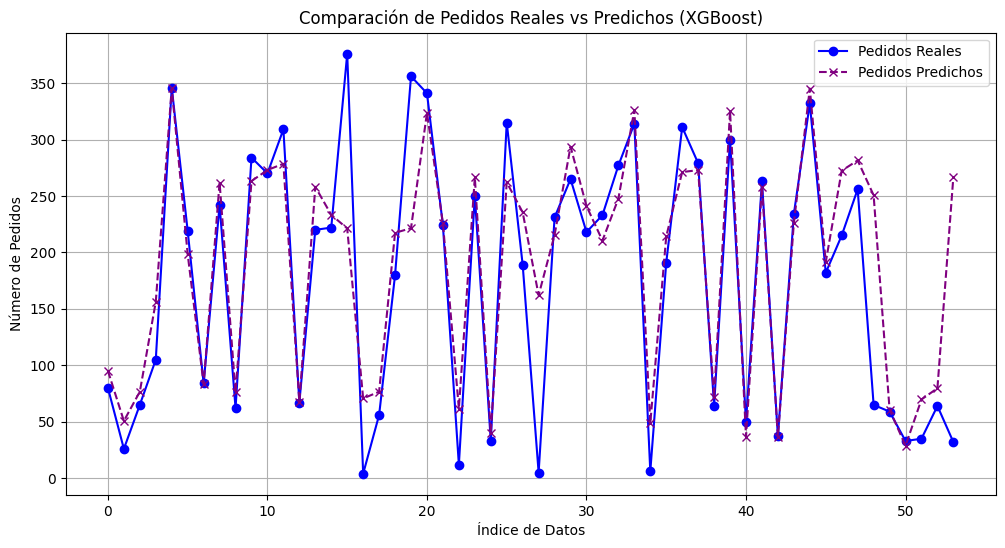

In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import matplotlib.pyplot as plt

# Cargar los datos desde el archivo de Excel
file_path = 'ConteoDias.xlsx'  # Asegúrate de subir este archivo a Colab
data = pd.read_excel(file_path)

# Convertir la columna de fecha al formato datetime y extraer el día de la semana
data['fecha'] = pd.to_datetime(data['fecha'], errors='coerce')
data['day_of_week'] = data['fecha'].dt.dayofweek

# Crear la columna de precipitación media (día actual y día anterior)
data['prcp_media'] = (data['prcp'] + data['prcp'].shift(1)) / 2

# Crear la columna de precipitación acumulada ponderada para los últimos 6 días
pesos = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
data['prcp_ponderada'] = (
    data['prcp'] * pesos[5] +
    data['prcp'].shift(1) * pesos[4] +
    data['prcp'].shift(2) * pesos[3] +
    data['prcp'].shift(3) * pesos[2] +
    data['prcp'].shift(4) * pesos[1] +
    data['prcp'].shift(5) * pesos[0]
)

# Crear características adicionales
data['lluvia_alta'] = data['prcp_media'].apply(lambda x: 1 if x > 100 else 0)
data['en_vacaciones'] = data['fecha'].apply(lambda x: 1 if (x.month == 8 and 8 <= x.day <= 28) else 0)
data['impacto_lluvia'] = data['prcp'].apply(lambda x: 1.3 if x > 25 else 1)

# Crear las variables "Pedidos del Día Anterior" y "Pedidos de Hace Dos Días"
data['orders_lag1'] = data['pedidos'].shift(1)
data['orders_lag2'] = data['pedidos'].shift(2)
data = data.dropna().reset_index(drop=True)

# Seleccionar las características relevantes para el modelo
X_features = data[['prcp_media', 'prcp_ponderada', 'lluvia_alta', 'en_vacaciones',
                   'impacto_lluvia', 'orders_lag1', 'orders_lag2', 'day_of_week']]
y = data['pedidos']

# División en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

# Entrenar el modelo usando XGBoost
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Guardar el modelo entrenado
model_path = 'XGBoostPedidosDeManana_Ajustado.joblib'
joblib.dump(model, model_path)
print(f"Modelo guardado en: {model_path}")

# Evaluación del modelo
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")

# Visualización de las predicciones
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test, label="Pedidos Reales", marker='o', linestyle='-', color="blue")
plt.plot(range(len(y_pred)), y_pred, label="Pedidos Predichos", marker='x', linestyle='--', color="purple")
plt.xlabel("Índice de Datos")
plt.ylabel("Número de Pedidos")
plt.title("Comparación de Pedidos Reales vs Predichos (XGBoost)")
plt.legend()
plt.grid()
plt.show()
